In [2]:
# declare libraries
import json
import geojson
import pathlib
import time
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely

import pprint as pp

from zipfile import ZipFile
import rioxarray as rxr
import xarray as xr
import rasterio as rio
from rasterio.plot import show
from rasterio.merge import merge
import glob

from whitebox import WhiteboxTools

import matplotlib.pyplot as plt

import requests
from requests.auth import HTTPBasicAuth
from planet import Session, DataClient, OrdersClient, Auth, Planet

import os
import sys

from rasterio.warp import calculate_default_transform, reproject, Resampling

sys.path.append("../utils")

In [116]:
path = "/data/wildfire_prep/full_planet/unzipped/2019/jun/files/"

ndvi_list = []
for file in os.listdir(path=path):
    if "AnalyticMS_SR_clip_bandmath.tif" in file:
        ndvi_list.append(f"{path}{file}")

len(ndvi_list)

572

In [119]:
ndvi_test = rxr.open_rasterio(ndvi_list[0])
ndvi_reproj = ndvi_test.rio.reproject("EPSG:4326")

ndvi_reproj.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [4]:
# fig, ax = plt.subplots()

# ndvi_test.to_array().plot.imshow(robust=True)

In [5]:
# xds = xr.open_dataset(ndvi_list[0], decode_coords="all")
# xds_reproj = xds.rio.reproject("EPSG:4326")

# xds_reproj.to_dataarray().squeeze().sel(band = 5)

In [80]:
ndvi_globs = []

for i in enumerate(ndvi_list):
    # print(glob.glob(i[1]))
    cur_glob = glob.glob(i[1])
    globals()[f"tif_glob_{i[0]}"] = rio.open(cur_glob[0])
    ndvi_globs.append( globals()[f"tif_glob_{i[0]}"] )

In [ ]:
tif_files = glob.glob(f"{path}*AnalyticMS_SR_clip_bandmath.tif")
sources = [rio.open(f) for f in tif_files]

# arrays = [src.read() for src in sources]

In [93]:
len(arrays)

572

In [ ]:
target_crs = "EPSG:3310"
output_dir = "/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/"
# output_fp = f"{output_dir}/{f.split('/')[-1].replace('.tif', '_reprojected.tif')}" 


In [ ]:
response = input("This cell will write a bunch of reprojected tifs to the data folder. Run it? (yes/no): ")
if response.lower() == "yes":

    for f in tif_files:
        with rio.open(f) as src:
            transform, width, height = calculate_default_transform(src.crs, target_crs, src.width, src.height, *src.bounds)
            kwargs = src.meta.copy()
            kwargs.update({"crs": target_crs, "transform": transform, "width": width, "height": height})

            print(f)
            output_fp = f"{output_dir}{f.split('/')[-1].replace('.tif', '_reprojected.tif')}" 

            with rio.open(output_fp, "w", **kwargs) as dst:
                for i in range(1, src.count + 1):  # Loop through bands
                    reproject(
                        source=rio.band(src, i),
                        destination=rio.band(dst, i),
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=transform,
                        dst_crs=target_crs,
                        resampling=Resampling.nearest
                    )

    print("Cell executed!")
else:
    print("Execution canceled.")

In [83]:
# reproj_tif_files = glob.glob(f"{output_dir}*/AnalyticMS_SR_clip_bandmath.tif")

reproj_tif_files = []

for file in os.listdir(path=output_dir):
    if "AnalyticMS_SR_clip_bandmath_reprojected.tif" in file:
        reproj_tif_files.append(f"{output_dir}/{file}")

reproj_sources = [rio.open(f) for f in reproj_tif_files]

In [96]:
# for src in sources:
#     print(src.count)  # Print number of bands in each file

for f in reproj_tif_files:
    with rio.open(f) as src:
        print(f"{f} → {src.crs}")  # ✅ Print CRS of each file


/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190627_172324_100d_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif → EPSG:3310
/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190607_182112_0f15_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif → EPSG:3310
/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190622_172359_0f21_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif → EPSG:3310
/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190624_182238_1009_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif → EPSG:3310
/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190623_172138_0f4d_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif → EPSG:3310
/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190604_182114_1003_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif → EPSG:3310
/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190628_

In [106]:
reproj_tif_files = glob.glob(f"{output_dir}*AnalyticMS_SR_clip_bandmath_reprojected.tif")
reproj_sources = [rio.open(f) for f in reproj_tif_files]

In [108]:
reproj_sources

[<open DatasetReader name='/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190627_172324_100d_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif' mode='r'>,
 <open DatasetReader name='/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190607_182112_0f15_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif' mode='r'>,
 <open DatasetReader name='/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190622_172359_0f21_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif' mode='r'>,
 <open DatasetReader name='/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190624_182238_1009_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif' mode='r'>,
 <open DatasetReader name='/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/20190623_172138_0f4d_3B_AnalyticMS_SR_clip_bandmath_reprojected.tif' mode='r'>,
 <open DatasetReader name='/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/

In [109]:
mosaic, out_transform = merge(reproj_sources)

In [114]:
out_meta = sources[0].meta.copy()
out_meta.update({"driver": "GTiff", "height": mosaic.shape[1], "width": mosaic.shape[2], "transform": out_transform})

# with rio.open("/data/wildfire_prep/full_planet/unzipped/2019/jun/output_ndvi_mosaic.tif", "w", **out_meta) as dest:
#     dest.write(mosaic)


with rio.open("/data/wildfire_prep/full_planet/unzipped/2019/jun/mosaic.tif", "w", **out_meta) as dest:
    dest.write(mosaic)  # ✅ Saves merged raster as a si


In [57]:
%pwd

'/capstone/wildfire_prep/josh/data-preparation/code/planet_tests'

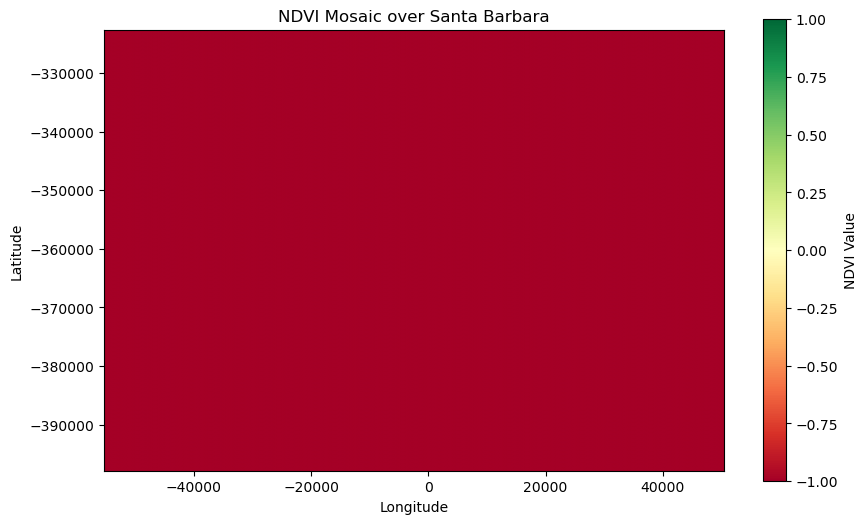

In [74]:
# Open raster & get extent
with rio.open("/data/wildfire_prep/full_planet/unzipped/2019/jun/output_ndvi_mosaic.tif") as src:
    ndvi_array = src.read(5)
    ndvi_array = (ndvi_array / 10000) * 2 - 1
    bounds = src.bounds  # Get geographic bounds

# Define extent for plotting
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Plot with coordinates
plt.figure(figsize=(10, 6))
plt.imshow(ndvi_array, cmap="RdYlGn", extent=extent, origin="upper", vmin=-1, vmax=1)  # Set spatial extent
plt.colorbar(label="NDVI Value")
plt.title("NDVI Mosaic over Santa Barbara")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [70]:
np.unique(ndvi_array)

array([-1.    , -0.9838, -0.983 , ...,  0.0654,  0.0864,  0.1132])

In [73]:
print(np.max(ndvi_array))
print(np.min(ndvi_array))
print(np.mean(ndvi_array))

0.11319999999999997
-1.0
-0.9999379690086645


In [ ]:
# ndvi_xrs = []

# for i in enumerate(ndvi_list):
#     globals()[f"ndvi_{i[0]}"] = rxr.open_rasterio(i[1]).sel(band = 5)
#     ndvi_xrs.append(globals()[f"ndvi_{i[0]}"])

In [33]:
xr.merge(ndvi_xrs[0:5])

ValueError: unable to convert unnamed DataArray to a Dataset without providing an explicit name

In [4]:
input_path = "/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310/"
output_path = "/data/wildfire_prep/full_planet/unzipped/2019/jun/"

def main():
    #########################
    # Set up Whitebox tools #
    #########################
    wbt = WhiteboxTools()
    wbt.set_verbose_mode(True) # Sets verbose mode. If verbose mode is False, tools will not print output messages as they run
    wbt.set_compress_rasters(True) # Compressed TIF file format based on the DEFALTE algorithm
    
    ##########################
    # Set up tool parameters #
    ##########################
    input_directory = input_path # Input directory; change to match user environment
    output_directory = output_path # Output directory; change to match yours
    
    if os.path.isdir(output_directory) != True: # Creates output dir if it does not already exist 
        os.mkdir(output_directory)      
    
    ################
    # Run the tool #
    ################
    wbt.set_working_dir(input_directory) # Set the working dir: This should be teh location of the input files #
    outfile = os.path.join(output_directory,"mosaic_2.tif") # Create the output file by joining the output directory path with the name of file
    # Calls mosaic tool with nearest neighbour as the resampling method ("nn")
    if wbt.mosaic(
        output=outfile, 
        method = "nn"
    ) != 0:
        # Non-zero returns indicate an error.
        print('ERROR running mosaic')
    
    print("Complete!")

main()

Decompressing WhiteboxTools_linux_amd64.zip ...
WhiteboxTools package directory: /Users/jpcohen/.conda/envs/wildfire_prep/lib/python3.12/site-packages/whitebox
./whitebox_tools --run="Mosaic" --wd="/data/wildfire_prep/full_planet/unzipped/2019/jun/reprojected_files_3310" --output='/data/wildfire_prep/full_planet/unzipped/2019/jun/mosaic_2.tif' --method=nn -v --compress_rasters=True

****************************
* Welcome to Mosaic        *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Number of tiles: 572
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress

In [ ]:
with rio.open(f"{output_path}mosaic_2.tif") as src:
    mos = src.read()
    bounds = src.bounds

In [ ]:
# Define plot extent (real-world coordinates)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the NDVI mosaic
ax.imshow(mos.transpose(1,2,0), cmap="RdYlGn", extent=extent, origin="upper")  # ✅ NDVI colormap
geom.plot(ax = ax)

plt.colorbar(label="NDVI Value")
plt.title("Mosaic NDVI Over Santa Barbara")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


NameError: name 'ax' is not defined

Error in callback <function _draw_all_if_interactive at 0x7fb4e196ff60> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

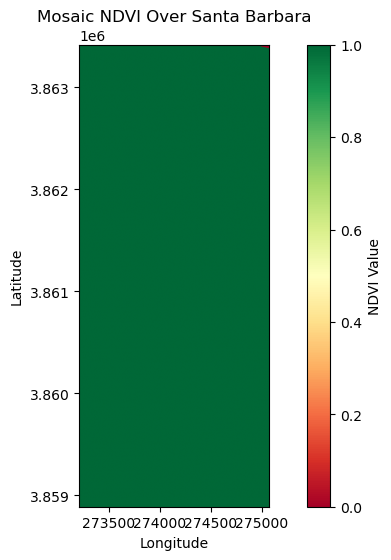

In [37]:
with rio.open(f"{output_path}files/20190617_181704_1005_3B_udm2_clip.tif") as src:
    frog = src.read()
    bounds = src.bounds

# Define plot extent (real-world coordinates)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Plot the NDVI mosaic
plt.figure(figsize=(10, 6))
plt.imshow(frog[7], cmap="RdYlGn", extent=extent, origin="upper")  # ✅ NDVI colormap
plt.colorbar(label="NDVI Value")
plt.title("Mosaic NDVI Over Santa Barbara")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [38]:
bounds

BoundingBox(left=273207.0, bottom=3858888.0, right=275064.0, top=3863418.0)

In [39]:
geom = gpd.read_file("/capstone/wildfire_prep/data/training_geometries/training_geometries_2019.geojson")

<Axes: >

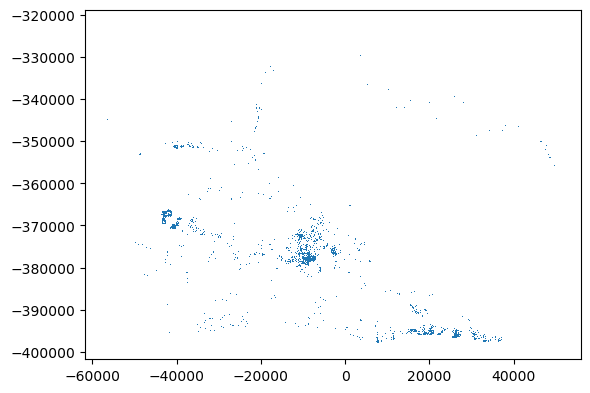

In [41]:
geom.plot()